In [1]:
year = 2023

In [2]:
from wind_wind.historical import get_generation, get_ARE_capacities

gen = get_generation(year)
cap = get_ARE_capacities(year)

historical_cf = gen/cap
historical_cf.name = f"Historical ({historical_cf.mean():.2%})"

In [3]:
historical_cf.mean()

np.float64(0.28222052874479997)

C:\coding\wind-wind\.venv\Lib\site-packages\pydantic\_internal\_generate_schema.py:663: ArbitraryTypeWarning: <module 'sqlite3' from 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.13_3.13.3824.0_x64__qbz5n2kfra8p0\\Lib\\sqlite3\\__init__.py'> is not a Python type (it may be an instance of an object), Pydantic will allow any object with no validation since we cannot even enforce that the input is an instance of the given type. To get rid of this error wrap the type with `pydantic.SkipValidation`.
  warnings.warn(


Cutout PL_2023.nc exists.
Cutout PL_2023.nc loaded.


INFO:atlite.data:Storing temporary files in C:\Users\Kajetan\AppData\Local\Temp\tmplk0hlcsd
INFO:atlite.convert:Convert and aggregate 'wind'.


25.597


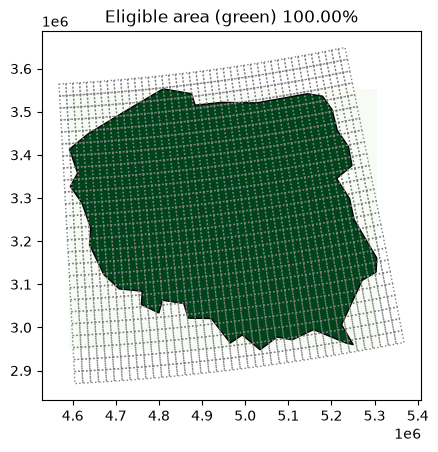

In [4]:
from wind_wind.profiles import Wind

cfs = []
turbine_name = "Vestas_V112_3MW"

wind_profile = Wind(turbine_name=turbine_name, smooth=False, weather_year=year)
wind_profile.generate()
atlite_default = wind_profile.profile
atlite_default.name = f"{turbine_name} ({atlite_default.mean():.2%})"
cfs.append(wind_profile.cf)
print(wind_profile.cf)


In [5]:
import pandas as pd
df = pd.concat([historical_cf, atlite_default], axis=1)
df

,Historical (28.22%),Vestas_V112_3MW (25.60%)
snapshot,,
2023-01-01 00:00:00,0.510692,0.951926
2023-01-01 01:00:00,0.375416,0.956298
2023-01-01 02:00:00,0.418898,0.957099
2023-01-01 03:00:00,0.511513,0.955202
2023-01-01 04:00:00,0.537454,0.942895
...,...,...
2023-12-31 19:00:00,0.406396,0.333433
2023-12-31 20:00:00,0.375298,0.317025
2023-12-31 21:00:00,0.363836,0.292259


<Axes: xlabel='snapshot'>

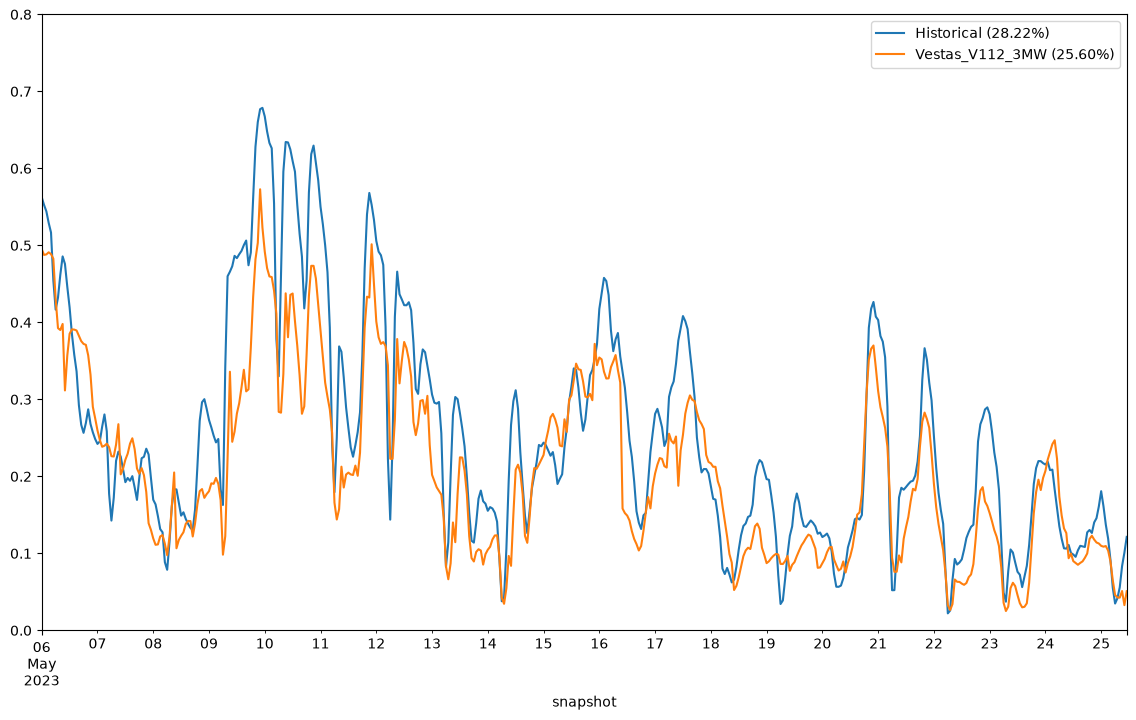

In [6]:
df[3000:3468].plot(figsize=(14,8), ylim=(0, 0.8))